# How to Match Catalogs

In [3]:
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
from astroquery.vizier import Vizier
from astropy import table
from astropy.table import Table, Column, MaskedColumn
import matplotlib.pyplot as plt

Cross-matching is the process of taking disparate catalogs and combining them into a singular, larger catalog. For astrophysical catalogs of stars, this is especially useful when combining datasets from different surveys, or even combining catalogs from different filters into one catalog for a single survey. 

Matching catalogs also comes in handy when assigning a WCS to an image, as known coordinates of stars can be assigned to cataloged positions of stars in the image. For images that come with a WCS, this can be used to improve the astrometry and even measure proper motion if the cataloging algorithms used are precise and accurate. 

While services like CDS XMatch can also merge catalogs, this can be done quickly on your own machine for smaller subsets of catalogs. This is useful for when you are working with cross-matching your own catalog with other datasets, especially when the data is not yet publicly available. 

For this example, we will work with public datasets. 

First, let us query some catalogs to match. 

In [4]:
# Choosing a position and size for the query
position = SkyCoord('17:46:21.4669695284', '-28:35:38.1118497742', unit=(u.hourangle, u.deg))
l = 1 * u.arcmin
w = 1 * u.arcmin

# Setting up the Vizier query. The Vizier class is a wrapper around the Vizier service, which is a tool to query astronomical catalogs.
# The Vizier class has a few parameters that can be set to control the behavior of the query:
# ROW_LIMIT: The maximum number of rows to return in the query result. This is useful to avoid downloading large catalogs.
# TIMEOUT: The maximum time to wait for the query to complete. This is useful to avoid waiting too long for a query to finish.
# VIZIER_SERVER: The Vizier server to use for the query. This is useful to specify a different server if the default one is down.
Vizier.ROW_LIMIT = 5e4
Vizier.TIMEOUT = 1800
Vizier.VIZIER_SERVER = 'vizier.cfa.harvard.edu/'

# Querying the Vista Variables in the Via Lactea (VVV) catalog
vvv_catalog_name = 'II/376/vvv4'
vvv_catalog = Vizier.query_region(coordinates=position, width=w, height=l, catalog=[vvv_catalog_name])[0]

# Querying the Gaia DR2 catalog
gaia_catalog_name = 'I/345/gaia2'
gaia_catalog = Vizier.query_region(coordinates=position, width=w, height=l, catalog=[gaia_catalog_name])[0]

# Establishing names for the catalogs that will be added to column names after merging.
vvv_catalog.meta['cat_name'] = 'VVV'
gaia_catalog.meta['cat_name'] = 'Gaia'

In [5]:
# Let's take a look at the VVV catalog
vvv_catalog[:3]

SrcID,RAJ2000,DEJ2000,Name,PriOrSec,H1-Ks1pnt,e_H1-Ks1pnt,H2-Ks2pnt,e_H2-Ks2pnt,Clst,Cl,pStar,pGal,pNoise,Z1MJD,Z1ap1,e_Z1ap1,Z1ap3,e_Z1ap3,Z1perrb,Z2MJD,Z2ap1,e_Z2ap1,Z2ap3,e_Z2ap3,Z2perrb,Y1MJD,Y1ap1,e_Y1ap1,Y1ap3,e_Y1ap3,Y1perrb,Y2MJD,Y2ap1,e_Y2ap1,Y2ap3,e_Y2ap3,Y2perrb,J1MJD,J1ap1,e_J1ap1,J1ap3,e_J1ap3,J1perrb,J2MJD,J2ap1,e_J2ap1,J2ap3,e_J2ap3,J2perrb,H1MJD,H1ap1,e_H1ap1,H1ap3,e_H1ap3,H1perrb,H2MJD,H2ap1,e_H2ap1,H2ap3,e_H2ap3,H2perrb,Ks1MJD,Ks1ap1,e_Ks1ap1,Ks1ap3,e_Ks1ap3,Ks1perrb,Ks2MJD,Ks2ap1,e_Ks2ap1,Ks2ap3,e_Ks2ap3,Ks2perrb,Var,Prim
,deg,deg,,,mag,mag,mag,mag,,,,,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,,
int64,float64,float64,str24,int64,float64,float64,float64,float64,float64,int16,float64,float64,float64,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,uint8,uint8
515856313177,266.584507,-28.601976,vvv J174620.28-283607.11,0,1.9542,0.1688,2.0988,0.1624,-1.5344,-1,0.999992,0.000008,0.000000,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,55423.17578818,16.5162,0.1198,16.6347,0.1513,--,57277.08989694,16.5174,0.1092,16.6237,0.1487,--,55423.17881078,14.7829,0.0767,14.6805,0.0749,--,57277.09227475,14.8804,0.0748,14.5249,0.0653,--,0,1
515856198119,266.581866,-28.600701,vvv J174619.65-283602.52,0,1.4700,0.0864,1.5013,0.0866,4.3030,1,0.003077,0.996923,0.000001,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,55423.18280082,18.6296,0.1943,18.5542,0.2038,--,57277.09516394,18.5212,0.1695,18.3820,0.1651,--,55423.17579123,15.8192,0.0633,15.7698,0.0684,--,57277.08989598,15.8206,0.0578,15.7861,0.0689,--,55423.17881190,14.2257,0.0461,14.2998,0.0528,16,57277.09226728,14.2050,0.0404,14.2849,0.0524,16,0,1
515856198166,266.583751,-28.599935,vvv J174620.10-283559.77,0,1.1628,0.2659,1.3536,0.2664,4.7991,1,0.000001,0.999999,0.000000,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,55423.18279364,18.5685,0.1838,18.5888,0.2103,--,--,--,--,--,--,--,55423.17578605,16.9100,0.1719,16.8578,0.1857,--,57277.08989509,16.9647,0.1646,16.9512,0.2009,--,55423.17880847,15.8024,0.1955,15.6949,0.1903,--,57277.09226567,15.7443,0.1652,15.5977,0.1749,--,0,1


In [6]:
# Let's take a look at the Gaia catalog
gaia_catalog[:3]

RA_ICRS,e_RA_ICRS,DE_ICRS,e_DE_ICRS,Source,Plx,e_Plx,pmRA,e_pmRA,pmDE,e_pmDE,Dup,FG,e_FG,Gmag,e_Gmag,FBP,e_FBP,BPmag,e_BPmag,FRP,e_FRP,RPmag,e_RPmag,BP-RP,RV,e_RV,Teff,AG,E(BP-RP),Rad,Lum
deg,mas,deg,mas,,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,,,,mag,mag,,,mag,mag,,,mag,mag,mag,km / s,km / s,K,mag,mag,solRad,solLum
float64,float64,float64,float64,int64,float64,float32,float64,float32,float64,float32,uint8,float32,float32,float64,float64,float32,float32,float64,float64,float32,float32,float64,float64,float64,float64,float32,float64,float32,float32,float32,float64
266.58281993599,0.2726,-28.60104122451,0.2250,4057520651815397504,0.2000,0.2447,-0.951,0.553,-1.860,0.396,0,564.4,1.459,18.8094,0.0028,91.55,12.69,20.4472,0.1505,892,44.13,17.3860,0.0537,3.0612,--,--,--,--,--,--,--
266.58790558098,1.0398,-28.59289709006,0.8432,4057520819328749440,1.8252,0.7005,-2.992,1.913,-1.872,1.443,0,166.5,1.181,20.1346,0.0077,66.36,15.47,20.7967,0.2530,194.2,8.335,19.0414,0.0466,1.7553,--,--,--,--,--,--,--
266.58721056527,1.0111,-28.58835223224,0.8098,4057520823614095360,2.0524,0.7226,-5.906,1.561,-4.266,1.220,0,184.8,1.305,20.0216,0.0077,69.22,11.4,20.7507,0.1788,223.7,16.76,18.8877,0.0813,1.8630,--,--,--,--,--,--,--


Immediately, we can see several similarities and differences between these two catalogs. Both catalogs give a position in Right Ascension and Declination for each star, but the names of the columns are different between the two catalogs. The different names correlate to the coordinate frame, VVV uses J2000 (or fk5 for the 2000 equinox, read more [here](https://docs.astropy.org/en/stable/coordinates/index.html#astropy-coordinates-overview)) and Gaia uses ICRS. 

There are many columns in both catalogs, but for now let's just deal with their coordinates.

In [7]:
vvv_coords = SkyCoord(ra=vvv_catalog['RAJ2000'], dec=vvv_catalog['DEJ2000'], unit=(u.deg, u.deg), frame='fk5')
gaia_coords = SkyCoord(ra=gaia_catalog['RA_ICRS'], dec=gaia_catalog['DE_ICRS'], unit=(u.deg, u.deg), frame='icrs')

# Because we want to match the VVV and Gaia catalogs, we need to convert the coordinates of the VVV catalog to the ICRS frame
vvv_coords = vvv_coords.transform_to('icrs')

vvv_catalog['skycoord'] = vvv_coords
gaia_catalog['skycoord'] = gaia_coords


Now that we have two catalogs of coordinates, let's try matching them. `astropy.coordinates.SkyCoord` comes with many functions for matching catalogs, so be sure to [check them out](https://docs.astropy.org/en/stable/api/astropy.coordinates.SkyCoord.html) and see if any other methods might be useful for your use case. 

In [8]:
# This is the closest two stars have to be to be matched. Note that increasing this value won't necessarily 
# increase the number of matches, as it will also increase the number of false positives. This also won't account for large
# offsets in the data. 
max_offset = 0.1*u.arcsec

# We are building a catalog that combines all of the stars, so we will start with a base catalog of Gaia sources and work from there
basecrds = gaia_coords.copy()
# We will match with the VVV catalog, defined here as crds
crds = vvv_coords.copy()

# We will match the catalogs in both directions to find the closest match for each star
matches, sep, _ = crds.match_to_catalog_sky(basecrds, nthneighbor=1)
reverse_matches, reverse_sep, _ = basecrds.match_to_catalog_sky(crds, nthneighbor=1)

# We will only keep the matches that are mutual, meaning that the closest match in one catalog is the same star in the other catalog
mutual_matches = (reverse_matches[matches] == np.arange(len(matches)))

# We will add the new sources to the base catalog
newcrds = crds[(sep > max_offset) & (~mutual_matches)]
basecrds = SkyCoord([basecrds,newcrds])

print('Base coord length = ', len(basecrds))
print('Added new sources = ', len(newcrds)) 

Base coord length =  334
Added new sources =  306


In [9]:
# Build the basetable, which should have ALL of the columns and combine the two tables
basetable = Table()
basetable['skycoord_ref'] = basecrds

tbls = [gaia_catalog, vvv_catalog]

for tb in tbls:
    # Grabbing the suffix we set earlier for the column names
    wl = tb.meta['cat_name']

    crds = tb['skycoord']

    # Matching each catalog to the basecrds catalog we made earlier
    matches, sep, _ = basecrds.match_to_catalog_sky(crds, nthneighbor=1)
    reverse_matches, reverse_sep, _ = crds.match_to_catalog_sky(basecrds, nthneighbor=1)
    mutual_matches = (reverse_matches[matches] == np.arange(len(matches)))

    # Adding in columns for the separation and the match ID
    basetable.add_column(name=f"sep_{wl}", col=sep)
    basetable.add_column(name=f"id_{wl}", col=matches)
    matchtb = tb[matches]
    badsep = sep > max_offset

    # Combining the catalogs fully by including all of their columns
    for cn in matchtb.colnames:
        if isinstance(matchtb[cn], SkyCoord):
            matchtb.rename_column(cn, f"{cn}_{wl}")
            matchtb[f'mask_{wl}'] = badsep
        else:
            matchtb[f'{cn}_{wl}'] = MaskedColumn(data=matchtb[cn], name=f'{cn}_{wl}')
            matchtb[f'{cn}_{wl}'].mask[badsep] = True
            # mask non-mutual matches
            matchtb[f'{cn}_{wl}'].mask[~mutual_matches] = True
            if hasattr(matchtb[cn], 'meta'):
                matchtb[f'{cn}_{wl}'].meta = matchtb[cn].meta
            matchtb.remove_column(cn)

    basetable = table.hstack([basetable, matchtb], join_type='exact')

In [10]:
# If we now look at the merged basetable, we should see that it contains all of the columns from both catalogs, with the appropriate suffixes
# and the new sources added to the base catalog. 
basetable[:3]

skycoord_ref,sep_Gaia,id_Gaia,skycoord_Gaia,RA_ICRS_Gaia,e_RA_ICRS_Gaia,DE_ICRS_Gaia,e_DE_ICRS_Gaia,Source_Gaia,Plx_Gaia,e_Plx_Gaia,pmRA_Gaia,e_pmRA_Gaia,pmDE_Gaia,e_pmDE_Gaia,Dup_Gaia,FG_Gaia,e_FG_Gaia,Gmag_Gaia,e_Gmag_Gaia,FBP_Gaia,e_FBP_Gaia,BPmag_Gaia,e_BPmag_Gaia,FRP_Gaia,e_FRP_Gaia,RPmag_Gaia,e_RPmag_Gaia,BP-RP_Gaia,RV_Gaia,e_RV_Gaia,Teff_Gaia,AG_Gaia,E(BP-RP)_Gaia,Rad_Gaia,Lum_Gaia,mask_Gaia,sep_VVV,id_VVV,skycoord_VVV,SrcID_VVV,RAJ2000_VVV,DEJ2000_VVV,Name_VVV,PriOrSec_VVV,H1-Ks1pnt_VVV,e_H1-Ks1pnt_VVV,H2-Ks2pnt_VVV,e_H2-Ks2pnt_VVV,Clst_VVV,Cl_VVV,pStar_VVV,pGal_VVV,pNoise_VVV,Z1MJD_VVV,Z1ap1_VVV,e_Z1ap1_VVV,Z1ap3_VVV,e_Z1ap3_VVV,Z1perrb_VVV,Z2MJD_VVV,Z2ap1_VVV,e_Z2ap1_VVV,Z2ap3_VVV,e_Z2ap3_VVV,Z2perrb_VVV,Y1MJD_VVV,Y1ap1_VVV,e_Y1ap1_VVV,Y1ap3_VVV,e_Y1ap3_VVV,Y1perrb_VVV,Y2MJD_VVV,Y2ap1_VVV,e_Y2ap1_VVV,Y2ap3_VVV,e_Y2ap3_VVV,Y2perrb_VVV,J1MJD_VVV,J1ap1_VVV,e_J1ap1_VVV,J1ap3_VVV,e_J1ap3_VVV,J1perrb_VVV,J2MJD_VVV,J2ap1_VVV,e_J2ap1_VVV,J2ap3_VVV,e_J2ap3_VVV,J2perrb_VVV,H1MJD_VVV,H1ap1_VVV,e_H1ap1_VVV,H1ap3_VVV,e_H1ap3_VVV,H1perrb_VVV,H2MJD_VVV,H2ap1_VVV,e_H2ap1_VVV,H2ap3_VVV,e_H2ap3_VVV,H2perrb_VVV,Ks1MJD_VVV,Ks1ap1_VVV,e_Ks1ap1_VVV,Ks1ap3_VVV,e_Ks1ap3_VVV,Ks1perrb_VVV,Ks2MJD_VVV,Ks2ap1_VVV,e_Ks2ap1_VVV,Ks2ap3_VVV,e_Ks2ap3_VVV,Ks2perrb_VVV,Var_VVV,Prim_VVV,mask_VVV
"deg,deg",deg,,"deg,deg",deg,mas,deg,mas,,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,,,,mag,mag,,,mag,mag,,,mag,mag,mag,km / s,km / s,K,mag,mag,solRad,solLum,,deg,,"deg,deg",,deg,deg,,,mag,mag,mag,mag,,,,,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,d,mag,mag,mag,mag,,,,
SkyCoord,float64,int64,SkyCoord,float64,float64,float64,float64,int64,float64,float32,float64,float32,float64,float32,uint8,float32,float32,float64,float64,float32,float32,float64,float64,float32,float32,float64,float64,float64,float64,float32,float64,float32,float32,float32,float64,bool,float64,int64,SkyCoord,int64,float64,float64,str24,int64,float64,float64,float64,float64,float64,int16,float64,float64,float64,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,float64,int32,uint8,uint8,bool
"266.58281993599,-28.60104122451",0.0,0,"266.58281993599,-28.60104122451",266.58281993599,0.2726,-28.60104122451,0.2250,4057520651815397504,0.2000,0.2447,-0.951,0.553,-1.860,0.396,0,564.4,1.459,18.8094,0.0028,91.55,12.69,20.4472,0.1505,892,44.13,17.3860,0.0537,3.0612,--,--,--,--,--,--,--,False,1.4840170108013698e-05,11,"266.5828030834402,-28.601042367278968",515854840786,266.582811,-28.601037,vvv J174619.87-283603.73,0,0.4479,0.0384,0.4651,0.0378,-3.7083,-1,1.000000,0.000000,0.000000,55803.13739613,16.3188,0.0141,16.3448,0.0111,--,57266.99383019,16.2637,0.0101,16.2606,0.0092,--,55803.13399047,15.5578,0.0100,15.5778,0.0088,16,57266.99050700,15.5599,0.0082,15.5442,0.0079,16,55423.18279928,14.8332,0.0078,14.8484,0.0078,16,57277.09516722,14.8332,0.0077,14.8455,0.0075,16,55423.17578825,14.1703,0.0143,14.2719,0.0174,--,57277.08989792,14.2108,0.0136,14.2664,0.0172,--,55423.17881198,13.6813,0.0281,13.8240,0.0342,16,57277.09226728,13.7164,0.0259,13.8013,0.0336,16,0,1,False
"266.58790558098,-28.59289709006",0.0,1,"266.58790558098,-28.59289709006",266.58790558098,1.0398,-28.59289709006,0.8432,4057520819328749440,1.8252,0.7005,-2.992,1.913,-1.872,1.443,0,166.5,1.181,20.1346,0.0077,66.36,15.47,20.7967,0.2530,194.2,8.335,19.0414,0.0466,1.7553,--,--,--,--,--,--,--,False,0.00039892550141134897,251,"266.5875180841936,-28.593105367513715",--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--

We can also evaluate how well the catalogs were matched by checking the offset between their coordinates.

In [13]:
dra = (basetable['skycoord_VVV'].ra - basetable['skycoord_ref'].ra).to(u.arcsec)
ddec = (basetable['skycoord_VVV'].dec - basetable['skycoord_ref'].dec).to(u.arcsec)

/orange/adamginsburg/miniconda3/envs/python310/lib/python3.10/site-packages/matplotlib/quiver.py:642: RuntimeWarning: Mean of empty slice.
  amean = a.mean()
/orange/adamginsburg/miniconda3/envs/python310/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


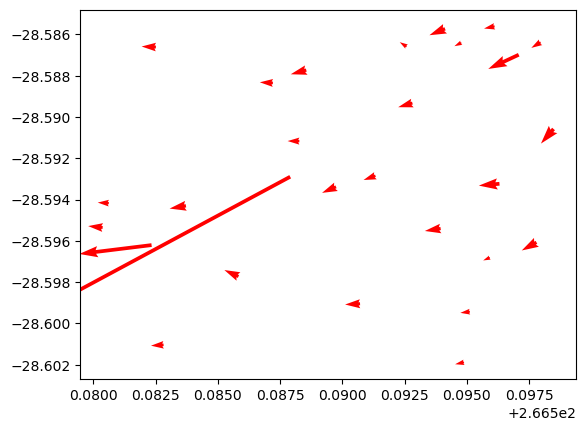

In [14]:
plt.quiver(basecrds[dra>0].ra.value, basecrds[dra>0].dec.value, dra.to(u.arcsec).value[dra>0], ddec.to(u.arcsec).value[dra>0], color='k')
plt.quiver(basecrds[dra<0].ra.value, basecrds[dra<0].dec.value, dra.to(u.arcsec).value[dra<0], ddec.to(u.arcsec).value[dra<0], color='r')

In [15]:
dra = (basetable['skycoord_Gaia'].ra - basetable['skycoord_ref'].ra).to(u.arcsec)
ddec = (basetable['skycoord_Gaia'].dec - basetable['skycoord_ref'].dec).to(u.arcsec)

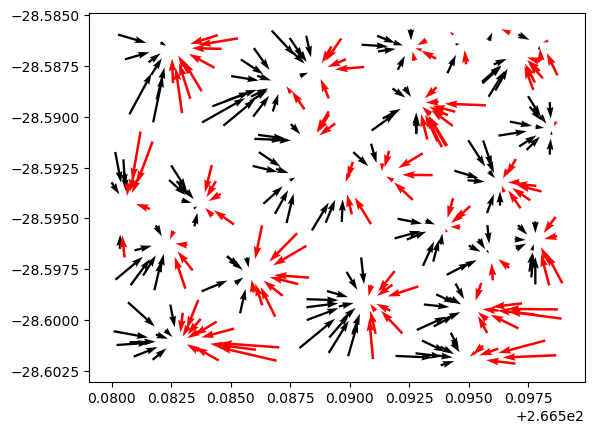

In [16]:
plt.quiver(basecrds[dra>0].ra.value, basecrds[dra>0].dec.value, dra.to(u.arcsec).value[dra>0], ddec.to(u.arcsec).value[dra>0], color='k')
plt.quiver(basecrds[dra<0].ra.value, basecrds[dra<0].dec.value, dra.to(u.arcsec).value[dra<0], ddec.to(u.arcsec).value[dra<0], color='r')